# ANÁLISE DE DADOS DE PREÇOS DE CASAS NOS ESTADOS UNIDOS
**Prof. M.Sc. Howard Roatti – FAESA Centro Universitário**

## Objetivo
Este projeto teve como objetivo entender quais fatores mais influenciam o preço de venda de imóveis nos Estados Unidos. A análise começou com uma exploração inicial dos dados, destacando variáveis como qualidade geral da casa, área construída, garagem e ano de construção.
Em seguida, foram aplicadas técnicas de feature engineering e modelos de aprendizagem supervisionada, com destaque para o Random Forest, que apresentou o melhor desempenho na previsão de preços. Na etapa não supervisionada, a clusterização e a redução de dimensionalidade ajudaram a revelar padrões entre os imóveis, enquanto a análise de outliers identificou observações incomuns no conjunto.
Como resultado, a análise mostrou que o valor das propriedades está fortemente associado a características estruturais e locacionais, tornando o projeto relevante tanto para estudos de ciência de dados quanto para aplicações no mercado imobiliário.

---

## 1️⃣ ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, silhouette_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# Configurações visuais
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'axes.facecolor': '#f8f9fa',
    'figure.facecolor': 'white',
    'font.size': 10
})

train_path = Path('data') / 'train.csv'
test_path = Path('data') / 'test.csv'

if train_path.exists() and test_path.exists():
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)
    print(f'✅ Dados carregados de {train_path} e {test_path}')
else:
    print('⚠️ Arquivo não encontrado.')

print(f'Forma dos dados de treino: {df_train.shape}')
print(f'Forma dos dados de teste: {df_test.shape}')
df_train.head()

✅ Dados carregados de data\train.csv e data\test.csv
Forma dos dados de treino: (1460, 81)
Forma dos dados de teste: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


🔗 TOP 15 CORRELAÇÕES COM PREÇO DE VENDA
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64


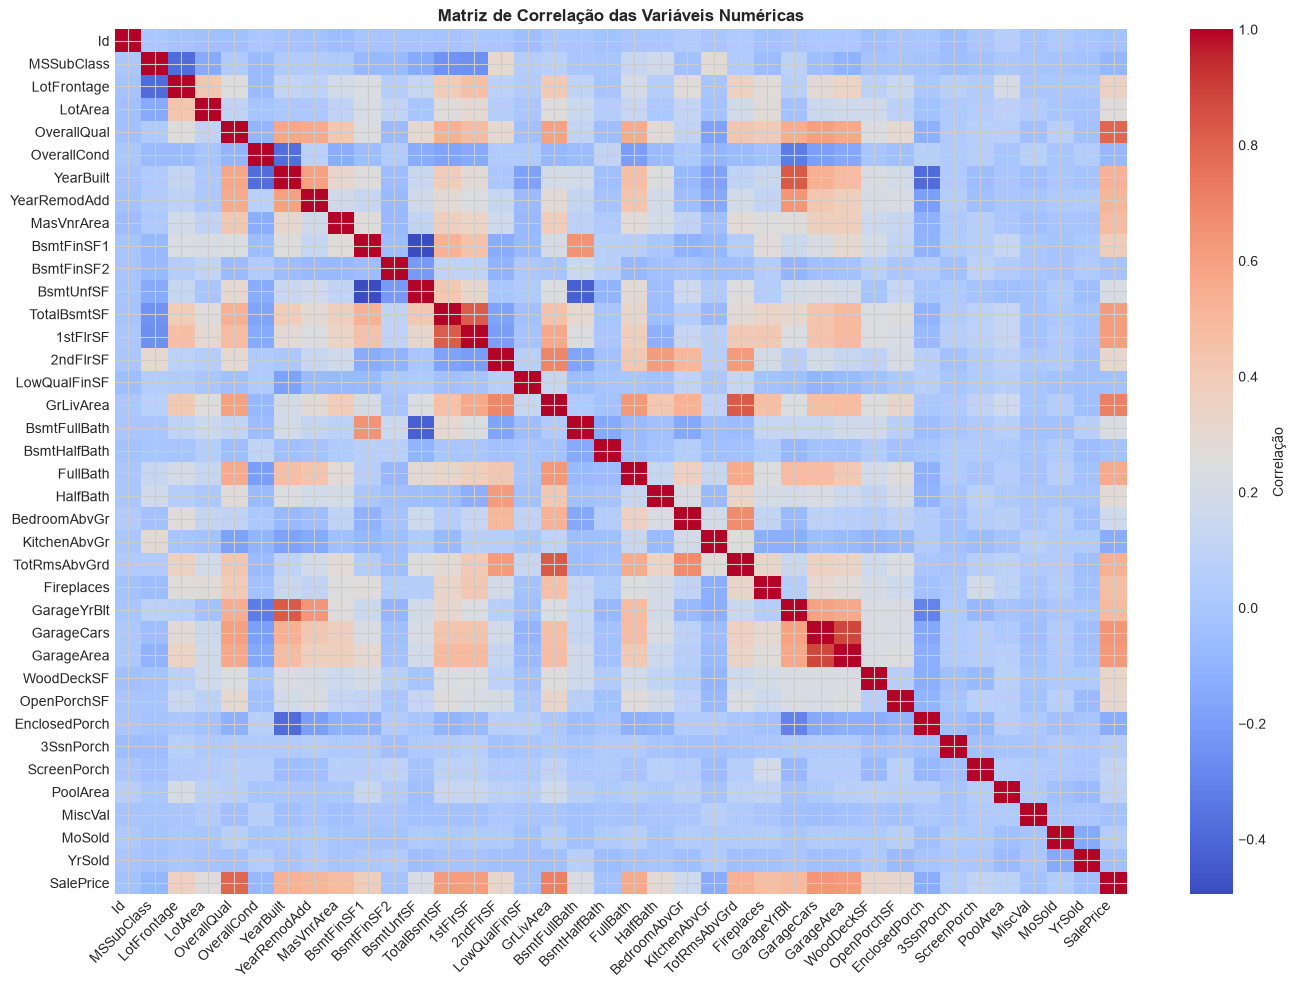

In [5]:
# Correlação entre variáveis numéricas
numeric_features = df_train.select_dtypes(include=[np.number]).columns
correlation_matrix = df_train[numeric_features].corr()

# Top correlações com SalePrice
top_corr = correlation_matrix['SalePrice'].sort_values(ascending=False)
print('🔗 TOP 15 CORRELAÇÕES COM PREÇO DE VENDA')
print(top_corr.head(16))

# Visualização da matriz de correlação
plt.figure(figsize=(14, 10))
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Correlação')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Matriz de Correlação das Variáveis Numéricas', fontweight='bold')
plt.tight_layout()
plt.savefig('01_matriz_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 2️⃣ FEATURE ENGINEERING

In [6]:
# 2. Codificar variáveis categóricas
print('\n🔤 CODIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS')

# Criar uma cópia do dataframe de treino para o pré-processamento
if 'df_model' not in globals():
    df_model = df_train.copy()

from sklearn.impute import SimpleImputer

label_encoders = {}
cat_cols = [col for col in df_model.select_dtypes(include=['object']).columns if col != 'SalePrice']
num_cols = df_model.select_dtypes(include=[np.number]).columns

for col in cat_cols:
    df_model[col] = df_model[col].fillna('Missing').astype(str)
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

imputer = SimpleImputer(strategy='median')
df_model[num_cols] = imputer.fit_transform(df_model[num_cols])

print(f'✅ {len(cat_cols)} variáveis categóricas codificadas e valores ausentes imputados')


🔤 CODIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS
✅ 43 variáveis categóricas codificadas e valores ausentes imputados


C:\Users\wanessa.guisso\AppData\Local\Temp\ipykernel_19092\2374260549.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = [col for col in df_model.select_dtypes(include=['object']).columns if col != 'SalePrice']


In [7]:
# 4. Normalização de features
print('\n📏 NORMALIZAÇÃO DE FEATURES')

X = df_model.drop('SalePrice', axis=1).copy()
y = df_model['SalePrice'].copy()

# Garantir que não existam valores ausentes nas features
if X.isnull().any().any():
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = X[col].fillna('Missing').astype(str)
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

    imputer = SimpleImputer(strategy='median')
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Split dos dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f'✅ Features normalizadas com StandardScaler')
print(f'Dados de treino: {X_train_scaled.shape}')
print(f'Dados de teste: {X_test_scaled.shape}')


📏 NORMALIZAÇÃO DE FEATURES
✅ Features normalizadas com StandardScaler
Dados de treino: (1168, 80)
Dados de teste: (292, 80)


## 3️⃣ APRENDIZAGEM SUPERVISIONADA: REGRESSÃO


2️⃣ RANDOM FOREST REGRESSOR
   RMSE: $28,523
   MAE:  $17,541
   R²:   0.8939


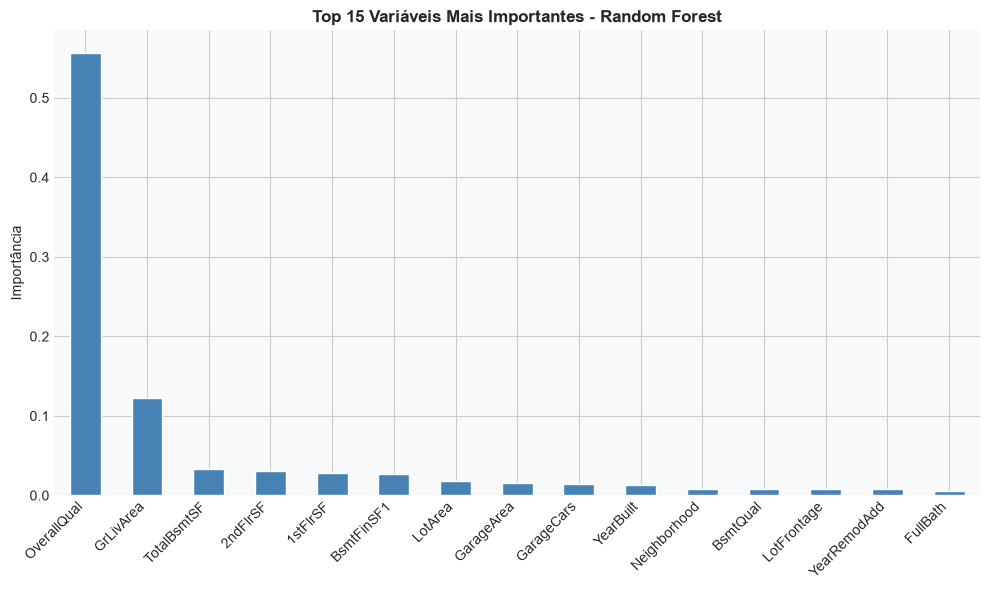

In [8]:
# 2. Random Forest Regressor
print('\n2️⃣ RANDOM FOREST REGRESSOR')

models_reg = {}
results_reg = {}

rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'   RMSE: ${rmse_rf:,.0f}')
print(f'   MAE:  ${mae_rf:,.0f}')
print(f'   R²:   {r2_rf:.4f}')

# Importância das features
feature_importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar', color='steelblue')
plt.title('Top 15 Variáveis Mais Importantes - Random Forest', fontweight='bold')
plt.ylabel('Importância')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('02_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

models_reg['Random Forest'] = rf
results_reg['Random Forest'] = {'RMSE': rmse_rf, 'MAE': mae_rf, 'R2': r2_rf, 'Predictions': y_pred_rf}

In [9]:
# Comparação dos modelos de regressão
print('\n' + '='*70)
print('📊 COMPARAÇÃO DOS MODELOS DE REGRESSÃO')
print('='*70)

comparison_reg = pd.DataFrame(results_reg).T[['RMSE', 'MAE', 'R2']]
print(comparison_reg)

best_model = comparison_reg['R2'].idxmax()
print(f'\n🏆 Melhor modelo: {best_model} (R² = {comparison_reg.loc[best_model, "R2"]:.4f})')


📊 COMPARAÇÃO DOS MODELOS DE REGRESSÃO
                       RMSE           MAE        R2
Random Forest  28523.020198  17540.656628  0.893934

🏆 Melhor modelo: Random Forest (R² = 0.8939)


## 4️⃣ APRENDIZAGEM SUPERVISIONADA: CLASSIFICAÇÃO

In [10]:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

models_clf = {}
results_clf = {}

# Transformar SalePrice em variável binária (alto ou baixo)
median_price = y.median()

y_train_clf = (y_train > median_price).astype(int)
y_test_clf = (y_test > median_price).astype(int)

X_train_clf = X_train.copy()
X_test_clf = X_test.copy()

if X_train_clf.isnull().any().any() or X_test_clf.isnull().any().any():
    imputer = SimpleImputer(strategy='median')
    X_train_clf = pd.DataFrame(imputer.fit_transform(X_train_clf), columns=X_train_clf.columns)
    X_test_clf = pd.DataFrame(imputer.transform(X_test_clf), columns=X_test_clf.columns)

scaler = StandardScaler()
X_train_clf_scaled = pd.DataFrame(scaler.fit_transform(X_train_clf), columns=X_train_clf.columns)
X_test_clf_scaled = pd.DataFrame(scaler.transform(X_test_clf), columns=X_test_clf.columns)

print('\n1️⃣ REGRESSÃO LOGÍSTICA')
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_clf_scaled, y_train_clf)

y_pred_log = log_reg.predict(X_test_clf_scaled)

acc_log = accuracy_score(y_test_clf, y_pred_log)
print(f'   Acurácia: {acc_log:.4f}')

models_clf['Logistic Regression'] = log_reg
results_clf['Logistic Regression'] = {'Accuracy': acc_log}



1️⃣ REGRESSÃO LOGÍSTICA
   Acurácia: 0.9452


In [11]:

print('\n2️⃣ ÁRVORE DE DECISÃO')

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_clf, y_train_clf)

y_pred_dt = dt.predict(X_test_clf)

acc_dt = accuracy_score(y_test_clf, y_pred_dt)
print(f'   Acurácia: {acc_dt:.4f}')

models_clf['Decision Tree'] = dt
results_clf['Decision Tree'] = {'Accuracy': acc_dt}



2️⃣ ÁRVORE DE DECISÃO
   Acurácia: 0.8870



📊 COMPARAÇÃO DOS MODELOS DE CLASSIFICAÇÃO
                     Accuracy
Logistic Regression  0.945205
Decision Tree        0.886986

🏆 Melhor modelo: Logistic Regression (Acurácia = 0.9452)


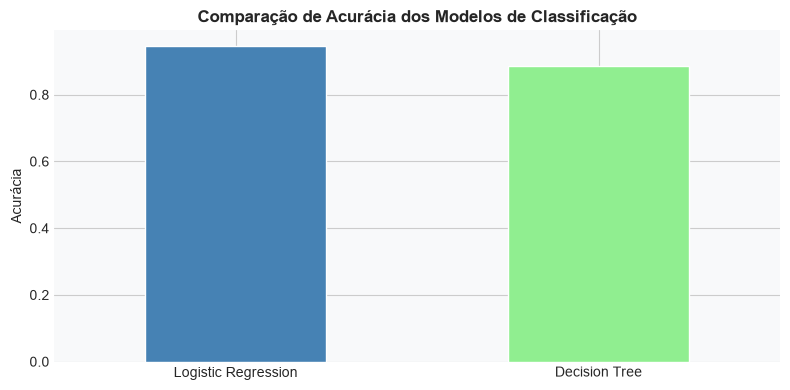

In [12]:
# Comparação dos modelos de classificação
print('\n' + '='*70)
print('📊 COMPARAÇÃO DOS MODELOS DE CLASSIFICAÇÃO')
print('='*70)

comparison_clf = pd.DataFrame(results_clf).T[['Accuracy']]
print(comparison_clf)

best_clf = comparison_clf['Accuracy'].idxmax()
print(f'\n🏆 Melhor modelo: {best_clf} (Acurácia = {comparison_clf.loc[best_clf, "Accuracy"]:.4f})')

plt.figure(figsize=(8, 4))
comparison_clf['Accuracy'].plot(kind='bar', color=['steelblue', 'lightgreen'])
plt.title('Comparação de Acurácia dos Modelos de Classificação', fontweight='bold')
plt.ylabel('Acurácia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('05_classificacao_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

## 5️⃣ APRENDIZAGEM NÃO SUPERVISIONADA: CLUSTERIZAÇÃO

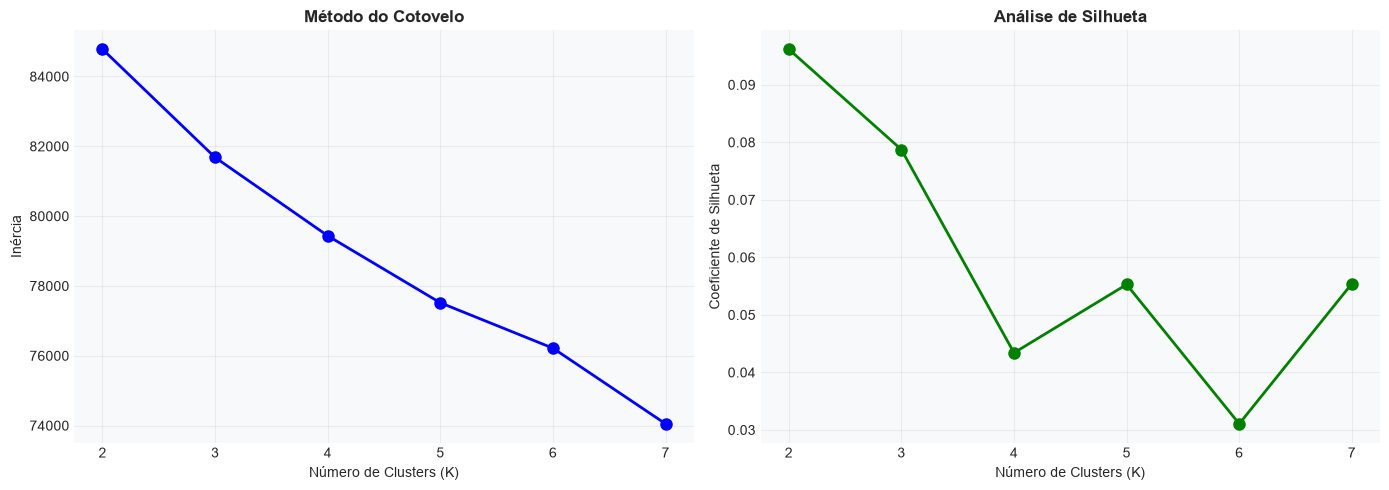


✅ K ótimo escolhido: 4


In [13]:
# Visualizar Elbow e Silhueta
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Preparar dados para clustering
X_clustering_scaled = X_train_scaled.copy()

# Avaliar diferentes números de clusters
K_range = range(2, 8)
inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_clustering_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_clustering_scaled, clusters))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia')
axes[0].set_title('Método do Cotovelo', fontweight='bold')
axes[0].grid(alpha=0.3)

# Silhueta
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Coeficiente de Silhueta')
axes[1].set_title('Análise de Silhueta', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('06_elbow_silhueta.png', dpi=150, bbox_inches='tight')
plt.show()

# Usar K=4 como ótimo
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_clustering_scaled)
print(f'\n✅ K ótimo escolhido: {optimal_k}')

c:\DESENVOLVIMENTO\WANESSA\c3A1\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\DESENVOLVIMENTO\WANESSA\c3A1\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


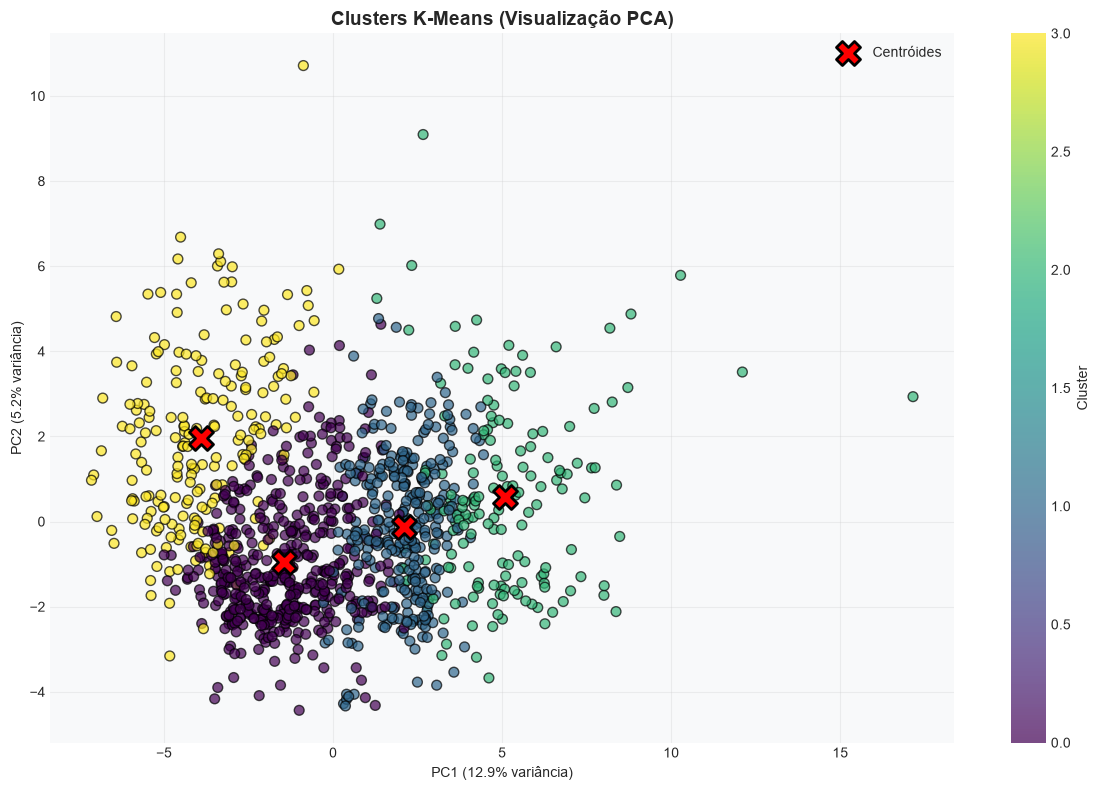

In [14]:
# Visualizar clusters usando PCA
pca_viz = PCA(n_components=2)
X_pca = pca_viz.fit_transform(X_clustering_scaled)

# Recalcular os rótulos de cluster a partir dos mesmos dados usados no PCA
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_clustering_scaled)

# Garantir que os arrays tenham o mesmo tamanho
if len(X_pca) != len(clusters):
    n_samples = min(len(X_pca), len(clusters))
    X_pca = X_pca[:n_samples]
    clusters = clusters[:n_samples]

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.7, edgecolors='k')
plt.scatter(pca_viz.transform(kmeans.cluster_centers_)[:, 0], 
           pca_viz.transform(kmeans.cluster_centers_)[:, 1], 
           c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centróides')
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% variância)')
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% variância)')
plt.title('Clusters K-Means (Visualização PCA)', fontweight='bold', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('07_kmeans_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
print('🎯 REDUÇÃO DE DIMENSIONALIDADE - PCA')
print('='*70)

# Aplicar PCA
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_clustering_scaled)

# Variância explicada
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

print('\n📊 VARIÂNCIA EXPLICADA PELAS COMPONENTES:')
for i, (var, cumvar) in enumerate(zip(pca_full.explained_variance_ratio_[:10], cumsum_var[:10])):
    print(f'   PC{i+1}: {var*100:.2f}% (Acumulada: {cumvar*100:.2f}%)')

# Número de componentes para 95% de variância
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
print(f'\n✅ Componentes necessárias para 95% de variância: {n_components_95}')

🎯 REDUÇÃO DE DIMENSIONALIDADE - PCA

📊 VARIÂNCIA EXPLICADA PELAS COMPONENTES:
   PC1: 12.94% (Acumulada: 12.94%)
   PC2: 5.21% (Acumulada: 18.15%)
   PC3: 4.85% (Acumulada: 22.99%)
   PC4: 3.74% (Acumulada: 26.73%)
   PC5: 3.16% (Acumulada: 29.89%)
   PC6: 2.81% (Acumulada: 32.70%)
   PC7: 2.45% (Acumulada: 35.16%)
   PC8: 2.26% (Acumulada: 37.41%)
   PC9: 2.16% (Acumulada: 39.57%)
   PC10: 2.00% (Acumulada: 41.58%)

✅ Componentes necessárias para 95% de variância: 60


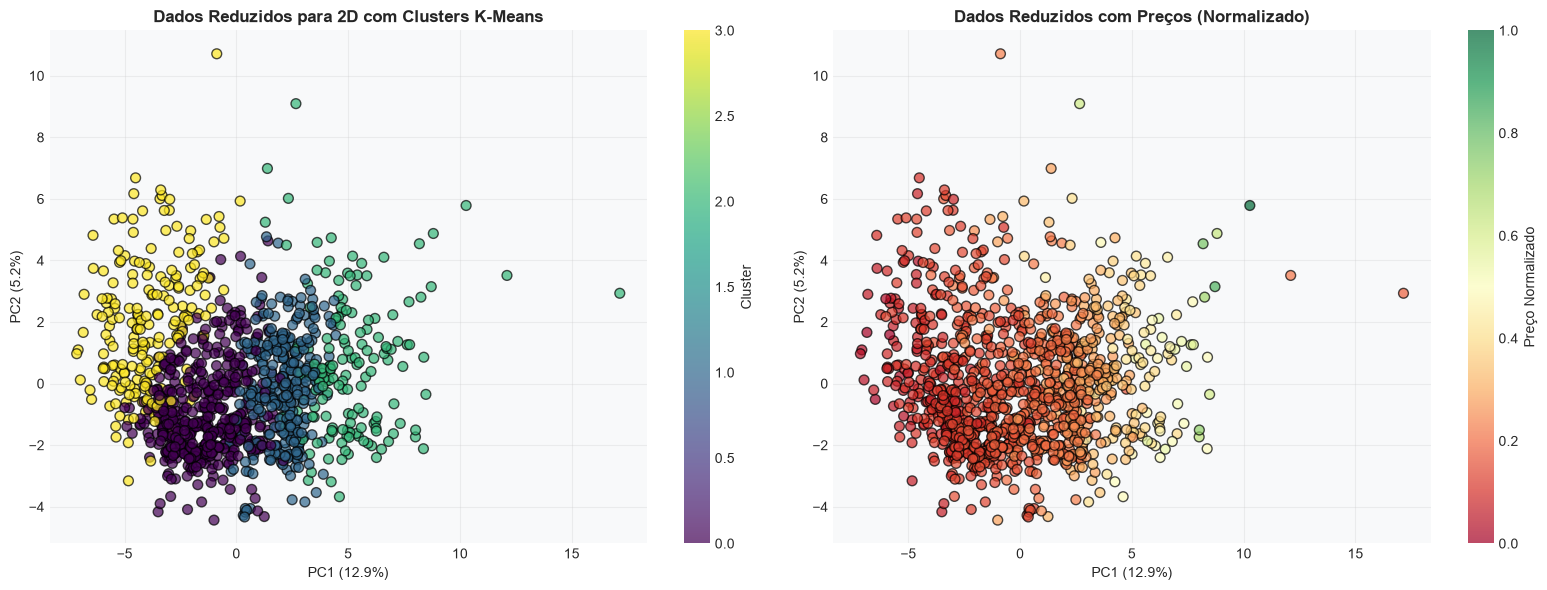


✅ Redução de 80 dimensões para 2 dimensões
   Variância explicada: 18.15%


In [16]:
# PCA com 2 componentes para visualização
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_clustering_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot com clusters
scatter = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=clusters, cmap='viridis', 
                         s=50, alpha=0.7, edgecolors='k')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Dados Reduzidos para 2D com Clusters K-Means', fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Cluster')
axes[0].grid(alpha=0.3)

# Scatter plot com preços
prices_normalized = (y_train - y_train.min()) / (y_train.max() - y_train.min())
scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=prices_normalized, cmap='RdYlGn', 
                          s=50, alpha=0.7, edgecolors='k')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Dados Reduzidos com Preços (Normalizado)', fontweight='bold')
plt.colorbar(scatter2, ax=axes[1], label='Preço Normalizado')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('09_pca_2d_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Redução de {X_clustering_scaled.shape[1]} dimensões para 2 dimensões')
print(f'   Variância explicada: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%')

In [17]:
print('🎯 DETECÇÃO DE OUTLIERS - LOCAL OUTLIER FACTOR (LOF)')
print('='*70)

# Aplicar LOF
lof = LocalOutlierFactor(n_neighbors=20)
outliers = lof.fit_predict(X_clustering_scaled)
outlier_scores = lof.negative_outlier_factor_

n_outliers = (outliers == -1).sum()
print(f'\n📊 RESULTADOS DA ANÁLISE DE OUTLIERS:')
print(f'   Total de outliers detectados: {n_outliers} ({n_outliers/len(outliers)*100:.2f}%)')
print(f'   Inliers: {(outliers == 1).sum()} ({(outliers == 1).sum()/len(outliers)*100:.2f}%)')

🎯 DETECÇÃO DE OUTLIERS - LOCAL OUTLIER FACTOR (LOF)

📊 RESULTADOS DA ANÁLISE DE OUTLIERS:
   Total de outliers detectados: 64 (5.48%)
   Inliers: 1104 (94.52%)



🎯 ANÁLISE DE ASSOCIAÇÃO COM APRIORI

📊 Top 10 Regras de Associação:


,antecedents,consequents,support,confidence,lift
59,"frozenset({BldgType_1Fam, MSZoning_RM})",frozenset({Neighborhood_OldTown}),0.056849,0.597122,7.715032
60,frozenset({Neighborhood_OldTown}),"frozenset({BldgType_1Fam, MSZoning_RM})",0.056849,0.734513,7.715032
57,"frozenset({Neighborhood_OldTown, BldgType_1Fam})",frozenset({MSZoning_RM}),0.056849,0.864583,5.790329
10,frozenset({Neighborhood_OldTown}),frozenset({MSZoning_RM}),0.065068,0.840708,5.630429
75,frozenset({Neighborhood_CollgCr}),"frozenset({BldgType_1Fam, Condition1_Norm, MSZ...",0.094521,0.920000,1.517740
72,"frozenset({BldgType_1Fam, Neighborhood_CollgCr})","frozenset({Condition1_Norm, MSZoning_RL})",0.094521,0.985714,1.443473
50,frozenset({Neighborhood_NridgHt}),"frozenset({Condition1_Norm, MSZoning_RL})",0.051370,0.974026,1.426357
41,frozenset({Neighborhood_Gilbert}),"frozenset({BldgType_1Fam, MSZoning_RL})",0.053425,0.987342,1.406360
74,"frozenset({MSZoning_RL, Neighborhood_CollgCr})","frozenset({BldgType_1Fam, Condition1_Norm})",0.094521,0.985714,1.379811
32,frozenset({Neighborhood_CollgCr}),"frozenset({Condition1_Norm, MSZoning_RL})",0.094521,0.920000,1.347242


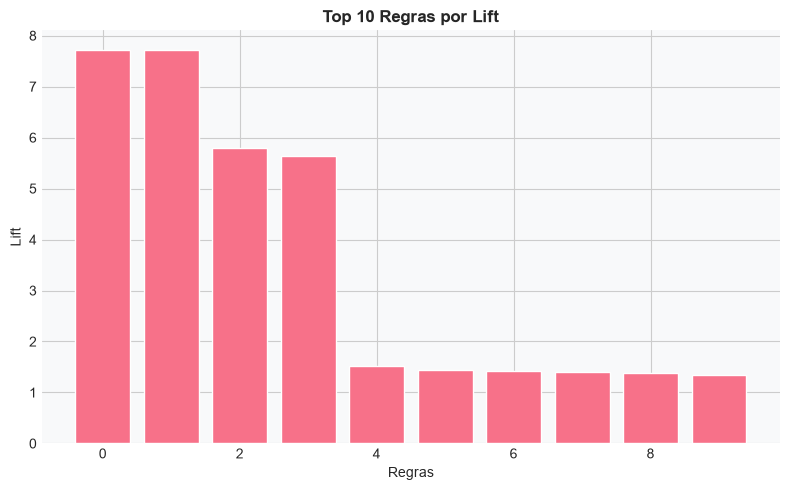

In [18]:
print('\n' + '='*70)
print('🎯 ANÁLISE DE ASSOCIAÇÃO COM APRIORI')
print('='*70)

features_assoc = ['MSZoning','Neighborhood','BldgType','Condition1']

assoc_df = df_train[features_assoc].astype(str)

transactions = pd.get_dummies(assoc_df)

frequent_itemsets = apriori(
    transactions,
    min_support=0.05,
    use_colnames=True
)

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.5
)

rules = rules.sort_values('lift', ascending=False)

print('\n📊 Top 10 Regras de Associação:')
display(
    rules[['antecedents','consequents','support','confidence','lift']]
    .head(10)
)

plt.figure(figsize=(8,5))
top_rules = rules.head(10)
plt.bar(range(len(top_rules)), top_rules['lift'])
plt.title('Top 10 Regras por Lift', fontweight='bold')
plt.ylabel('Lift')
plt.xlabel('Regras')
plt.tight_layout()
plt.savefig('11_apriori_lift.png', dpi=150, bbox_inches='tight')
plt.show()
